# 02 · Online Softmax

> 本 Notebook 从 Safe Softmax 出发，推导 Online Softmax 的更新公式，再把它用于分块注意力计算。

**目录**
1. [为什么需要 Online Softmax？](#1-为什么需要-Online-Softmax)
2. [Safe Softmax](#2-Safe-Softmax)
3. [Online Softmax 推导](#3-Online-Softmax-推导)
4. [带输出累积的 Online Attention](#4-带输出累积的-Online-Attention)
5. [分块 Online Attention](#5-分块-Online-Attention)
6. [数值精度分析](#6-数值精度分析)
7. [性能对比](#7-性能对比)
8. [小结与展望](#8-小结与展望)

---

## 1 为什么需要 Online Softmax？

01 的标准注意力先计算分数 $S$，再计算权重 $A$ 和输出 $O$：
$$
S=\frac{QK^\top}{\sqrt{d_k}},\qquad A=\text{softmax}(S),\qquad O=AV.
$$
沿用前一节的符号：序列长度 $N$，每头维度 $d_k$，批次大小 $B$，头数 $h$。本节先讨论单行，之后推广到形状为 $(B,h,N,d_k)$ 的输入，不使用 dropout。

标准实现把完整 $N\times N$ 的 $S,A$ 写入显存再读回。下面沿用论文的 HBM 名称来讨论这一层存储。如果只计算小块，就能避免保存这些大矩阵。但 softmax 的分母覆盖整行：
$$
\text{softmax}(x)_a=\frac{e^{x_a}}{\sum_{b=1}^N e^{x_b}}.
$$
只看到当前块，还不知道最终分母，不能直接把各块的 softmax 拼起来。

Online Softmax 一边扫描，一边更新最大值 $m$ 和分母 $\ell$，因此**一趟就能得到归一化统计量**。如果需要完整 softmax 向量，仍要再次访问输入或保存的中间值；如果只需要注意力输出 $O=AV$，可以同步累积输出，不必生成完整 $A$。

```text
Online Softmax：扫描 x，更新 (m, ℓ) → 再访问 x，输出完整 softmax
Online Attention：扫描 K/V，更新 (m, ℓ, 输出累积量) → 最后归一化输出
```

In [1]:
import platform
import sys
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
print(f"运行系统: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split()[0]}")

import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from contextlib import contextmanager

try:
    from torch.nn.attention import SDPBackend, sdpa_kernel
except ImportError:
    SDPBackend = None

@contextmanager
def select_backend(name):
    if SDPBackend is not None:
        backend = {'math': SDPBackend.MATH, 'flash': SDPBackend.FLASH_ATTENTION}[name]
        with sdpa_kernel(backend):
            yield
    else:
        import inspect
        options = dict(enable_flash=name == 'flash', enable_math=name == 'math',
                       enable_mem_efficient=False)
        if 'enable_cudnn' in inspect.signature(torch.backends.cuda.sdp_kernel).parameters:
            options['enable_cudnn'] = False
        with torch.backends.cuda.sdp_kernel(**options):
            yield

def run_standard(Q, K, V):
    with select_backend('math'):
        return F.scaled_dot_product_attention(Q, K, V, dropout_p=0.0)
validation_checks = []
precision_checks = []


运行系统: Linux 6.6.87.2-microsoft-standard-WSL2
Python: 3.10.12


PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2 Safe Softmax

### 2.1 朴素 Softmax 的数值问题

直接计算 $e^{x_a}$，可能因输入过大而溢出，或因输入过小而下溢。例如 FP32 上限约为 $3.4\times10^{38}$，而 $e^{89}$ 已超过该范围。

### 2.2 减去最大值

令 $m=\max_b x_b$，则：
$$
\text{softmax}(x)_a=\frac{e^{x_a-m}}{\sum_b e^{x_b-m}}.
$$
分子、分母同乘 $e^{-m}$，结果不变。对于有限输入，指数不超过 1，避免了指数溢出。很小的项仍可能下溢为 0，浮点误差也不会消失。

下面先用 FP32 有限输入演示。半精度计算还需要考虑分母求和和输出累积的精度；第 6 节使用 FP32 工作状态。

In [2]:
def naive_softmax(x: torch.Tensor) -> torch.Tensor:
    """朴素 softmax，不做处理。"""
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=-1, keepdim=True)


def safe_softmax(x: torch.Tensor) -> torch.Tensor:
    """Safe softmax：减去行最大值后再计算。"""
    work = x.float() if x.dtype in (torch.float16, torch.bfloat16) else x
    m = work.max(dim=-1, keepdim=True).values
    exp_x = torch.exp(work - m)
    return (exp_x / exp_x.sum(dim=-1, keepdim=True)).to(x.dtype)


# ---- 数值问题演示 ----
torch.manual_seed(0)
# 正常值
x_normal = torch.randn(8)
# 大值（会导致朴素版本溢出）
x_large = torch.tensor([100.0, 101.0, 99.0, 102.0, 98.0, 103.0, 97.0, 100.5])

print("=== 正常输入 ===")
ref = torch.softmax(x_normal, dim=-1)
naive = naive_softmax(x_normal)
safe = safe_softmax(x_normal)
print(f"safe 最大误差: {(safe - ref).abs().max():.2e}")

print("\n=== 大值输入 ===")
ref2 = torch.softmax(x_large, dim=-1)
naive2 = naive_softmax(x_large)
safe2 = safe_softmax(x_large)
print(f"naive 输出: {naive2.tolist()}")
print(f"safe 最大误差: {(safe2 - ref2).abs().max():.2e}")

assert torch.isnan(naive2).all()
torch.testing.assert_close(safe, ref, atol=1e-6, rtol=1e-5)
torch.testing.assert_close(safe2, ref2, atol=1e-6, rtol=1e-5)

=== 正常输入 ===
safe 最大误差: 1.49e-08

=== 大值输入 ===
naive 输出: [nan, nan, nan, nan, nan, nan, nan, nan]
safe 最大误差: 1.49e-08


大值输入使朴素版本的指数溢出，随后 `inf / inf` 得到 NaN。减去最大值后，这组输入可以正常计算。

### 2.3 扫描次数怎么算？

如果不保存整行指数，Safe Softmax 的直接实现需要三步：

1. 扫描输入，求最大值 $m$。
2. 再扫描输入，求 $\ell=\sum_b e^{x_b-m}$。
3. 再访问输入，计算每个 $e^{x_a-m}/\ell$。

如果第 2 步保存了所有指数，第 3 步可以读指数而不读原输入，但仍需遍历这些中间值。整行能放在片上时，融合实现可以复用数据；这里的逻辑扫描次数不等于实际 HBM 读取次数。

Online Softmax 把前两步合成一趟，边读边更新 $m,\ell$。完整权重仍要最后计算，而注意力输出可以与统计量一起累积。

参考：[Online normalizer 论文，Algorithm 2–3](https://arxiv.org/pdf/1805.02867)。

## 3 Online Softmax 推导

### 3.1 两个累积量

已扫描有限输入 $x_1,\ldots,x_t$ 后，维护：
$$
m^{(t)}=\max_{b\le t}x_b,\qquad
\ell^{(t)}=\sum_{b=1}^t e^{x_b-m^{(t)}}.
$$
初始值为 $m^{(0)}=-\infty,\ell^{(0)}=0$。扫描结束后，得到全局最大值和归一化分母。

### 3.2 更新公式与正确性

读入 $x_{t+1}$，先更新最大值：
$$
m^{(t+1)}=\max(m^{(t)},x_{t+1}).
$$
旧分母以 $m^{(t)}$ 为基准，需要换成新基准：
$$
\begin{aligned}
\ell^{(t+1)}
&=\sum_{b=1}^{t+1}e^{x_b-m^{(t+1)}}\\
&=e^{m^{(t)}-m^{(t+1)}}\ell^{(t)}+e^{x_{t+1}-m^{(t+1)}}.
\end{aligned}
$$
旧项全部乘上同一个系数，就能换成新最大值的基准。先不考虑浮点舍入，更新后的结果仍符合第 3.1 节的定义，所以最后得到的就是整行统计量。两个缩放指数都不大于 0，不会因指数过大而溢出。

下面逐元素更新张量状态，便于对照公式，也保留梯度计算。逐元素调用算子只适合教学；后面再改成块内向量化。

In [3]:
def online_softmax_scalar(x: torch.Tensor) -> torch.Tensor:
    """一趟求 (m, ell)，然后再次访问 x，输出完整 softmax。"""
    if x.ndim != 1 or x.numel() == 0 or not x.is_floating_point():
        raise ValueError('本示例要求非空的一维有限浮点输入')
    output_dtype = x.dtype
    work = x.float() if x.dtype in (torch.float16, torch.bfloat16) else x
    m, ell = work.new_tensor(float('-inf')), work.new_tensor(0.0)
    for xi in work:
        m_new = torch.maximum(m, xi)
        ell = torch.exp(m - m_new) * ell + torch.exp(xi - m_new)
        m = m_new
    # 这里再次访问整行输入，并非只扫描一次就输出完整 softmax。
    return (torch.exp(work - m) / ell).to(output_dtype)

torch.manual_seed(42)
x_test = torch.randn(32, device=device)
for x in [x_test, x_test * 50]:
    ref_out = torch.softmax(x, dim=0)
    online_out = online_softmax_scalar(x)
    torch.testing.assert_close(online_out, ref_out, atol=1e-6, rtol=1e-5)
    print(f'标量 Online Softmax 最大绝对误差：{(online_out-ref_out).abs().max().item():.2e}')

标量 Online Softmax 最大绝对误差：1.49e-08
标量 Online Softmax 最大绝对误差：0.00e+00


这两组输入通过了与 `torch.softmax` 的误差检查。具体误差随输入、数据类型和运算顺序变化。

### 3.3 块级更新

把一行分成每块最多 $B_c$ 个元素的块，记第 $j$ 块的位置集合为 $\mathcal C_j$。当前块的统计量为：
$$
\tilde m_j=\max_{b\in\mathcal C_j}x_b,\qquad
\tilde\ell_j=\sum_{b\in\mathcal C_j}e^{x_b-\tilde m_j}.
$$
与旧统计量合并：
$$
m^{\text{new}}=\max(m^{\text{old}},\tilde m_j),
$$
$$
\ell^{\text{new}}=e^{m^{\text{old}}-m^{\text{new}}}\ell^{\text{old}}
+e^{\tilde m_j-m^{\text{new}}}\tilde\ell_j.
$$
两个分母先换成相同基准，再相加，与标量更新相同。多行输入时，每行独立维护一组 $m,\ell$，不是整块共用一个标量。

In [4]:
def online_softmax_blocked(x: torch.Tensor, block_size: int = 8) -> torch.Tensor:
    """按块求统计量，再访问整行，输出 softmax。输入为有限浮点数。"""
    if x.ndim != 1 or x.numel() == 0 or not x.is_floating_point():
        raise ValueError("输入必须是非空一维浮点张量")
    if not isinstance(block_size, int) or block_size <= 0:
        raise ValueError('输入应为非空一维张量，块大小应为正数')
    output_dtype = x.dtype
    work = x.float() if x.dtype in (torch.float16, torch.bfloat16) else x
    m, ell = work.new_tensor(float('-inf')), work.new_tensor(0.0)
    for xb in work.split(block_size):
        m_tilde = xb.max()
        ell_tilde = torch.exp(xb - m_tilde).sum()
        m_new = torch.maximum(m, m_tilde)
        ell = torch.exp(m - m_new) * ell + torch.exp(m_tilde - m_new) * ell_tilde
        m = m_new
    return (torch.exp(work - m) / ell).to(output_dtype)

torch.manual_seed(7)
x_val = torch.randn(67, device=device)
ref_val = torch.softmax(x_val, dim=0)
for bs in [1, 4, 8, 16, 32, 64, 128]:
    out = online_softmax_blocked(x_val, block_size=bs)
    torch.testing.assert_close(out, ref_val, atol=1e-6, rtol=1e-5)
    print(f'块大小={bs:3d}，最大绝对误差={(out-ref_val).abs().max().item():.2e}')

块大小=  1，最大绝对误差=1.49e-08
块大小=  4，最大绝对误差=0.00e+00


块大小=  8，最大绝对误差=0.00e+00
块大小= 16，最大绝对误差=0.00e+00
块大小= 32，最大绝对误差=0.00e+00
块大小= 64，最大绝对误差=0.00e+00
块大小=128，最大绝对误差=0.00e+00


### 3.4 统计量可以按不同顺序合并

对于两个不重叠的数据块 $U,W$，令 $m^*=\max(m_U,m_W)$，定义：
$$
(m_U,\ell_U)\oplus(m_W,\ell_W)
=\left(m^*,e^{m_U-m^*}\ell_U+e^{m_W-m^*}\ell_W\right).
$$
合并结果就是两个块放在一起后的最大值和分母。如果先不考虑浮点舍入，先合并前两个块还是后两个块，结果都一样，这就是结合律。代码里改变合并顺序可能带来小的浮点误差。

这允许各块先独立计算，再合并。要合并注意力输出，还要用同样的系数合并输出分子：
$$
\tilde O_{U\cup W}=e^{m_U-m^*}\tilde O_U+e^{m_W-m^*}\tilde O_W.
$$
最后用合并后的 $\ell$ 归一化。第 4 节说明这个输出分子如何维护。

In [5]:
def merge_stats(
    m_a: torch.Tensor, ell_a: torch.Tensor,
    m_b: torch.Tensor, ell_b: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """合并两个 (m, ℓ) 统计量"""
    m_new = torch.maximum(m_a, m_b)
    ell_new = torch.exp(m_a - m_new) * ell_a + torch.exp(m_b - m_new) * ell_b
    return m_new, ell_new


def compute_stats(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """计算一个向量块的 (m, ℓ)。"""
    m = x.max()
    ell = torch.exp(x - m).sum()
    return m, ell


torch.manual_seed(0)
x64 = torch.randn(64)

# 方案 A：顺序归约 4 块
blocks = x64.split(16)  # 4 块，每块 16
m_seq, ell_seq = compute_stats(blocks[0])
for blk in blocks[1:]:
    m_seq, ell_seq = merge_stats(m_seq, ell_seq, *compute_stats(blk))

# 方案 B：树状归约
stats_list = [compute_stats(b) for b in blocks]
m_t01, ell_t01 = merge_stats(*stats_list[0], *stats_list[1])
m_t23, ell_t23 = merge_stats(*stats_list[2], *stats_list[3])
m_tree, ell_tree = merge_stats(m_t01, ell_t01, m_t23, ell_t23)

# 参考：全局一次性计算
m_ref = x64.max()
ell_ref = torch.exp(x64 - m_ref).sum()

print("验证可结合性：")
print(f"顺序合并  m={m_seq.item():.6f}, ℓ={ell_seq.item():.6f}")
print(f"树状归约  m={m_tree.item():.6f}, ℓ={ell_tree.item():.6f}")
print(f"全局参考  m={m_ref.item():.6f}, ℓ={ell_ref.item():.6f}")

assert abs(m_seq.item() - m_ref.item()) < 1e-6
assert abs(m_tree.item() - m_ref.item()) < 1e-6
assert abs(ell_seq.item() - ell_ref.item()) < 1e-4
assert abs(ell_tree.item() - ell_ref.item()) < 1e-4

验证可结合性：
顺序合并  m=3.410503, ℓ=4.378253
树状归约  m=3.410503, ℓ=4.378253
全局参考  m=3.410503, ℓ=4.378253


## 4 带输出累积的 Online Attention

### 4.1 同步累积输出分子

先看单个 query $q\in\mathbb R^{d_k}$。第 $b$ 个 key/value 分别为 $k_b,v_b$，分数为 $s_b=q^\top k_b/\sqrt{d_k}$。与统计量一起维护：
$$
\tilde O^{(t)}=\sum_{b=1}^{t}e^{s_b-m^{(t)}}v_b.
$$
$\tilde O$ 是未归一化的输出，初始值为零向量。读入新 key/value 后：
$$
\tilde O^{(t+1)}=e^{m^{(t)}-m^{(t+1)}}\tilde O^{(t)}
+e^{s_{t+1}-m^{(t+1)}}v_{t+1}.
$$
与分母一样，先修正旧项的基准，再加入新项。最终：
$$
O=\frac{\tilde O^{(N)}}{\ell^{(N)}}.
$$
这样每个 key/value 只需参与一轮更新，不必输出整行权重再做加权求和。

也可以每步维护已归一化的 $O^{(t)}=\tilde O^{(t)}/\ell^{(t)}$：
$$
O^{(t+1)}=
\frac{e^{m^{(t)}-m^{(t+1)}}\ell^{(t)}}{\ell^{(t+1)}}O^{(t)}
+\frac{e^{s_{t+1}-m^{(t+1)}}}{\ell^{(t+1)}}v_{t+1}.
$$
下面单 query 示例维护 $\tilde O$，最后归一化；第 5 节按论文 Algorithm 1 维护已归一化的 $O$。

In [6]:
def online_attention_1d(q: torch.Tensor, K: torch.Tensor, V: torch.Tensor) -> torch.Tensor:
    """单个 query，逐 key 更新未归一化输出。输入形状为 (d_k)、(N,d_k)。"""
    if K.ndim != 2 or q.shape != K.shape[1:] or V.shape != K.shape or K.size(0) == 0:
        raise ValueError('本示例要求 q 为 (d_k)，K,V 为相同的非空 (N,d_k)')
    output_dtype = q.dtype
    if q.dtype in (torch.float16, torch.bfloat16):
        q, K, V = q.float(), K.float(), V.float()
    scale = 1 / math.sqrt(q.numel())
    m, ell = q.new_tensor(float('-inf')), q.new_tensor(0.0)
    O_tilde = torch.zeros_like(q)
    for k_j, v_j in zip(K, V):
        s_j = (q @ k_j) * scale
        m_new = torch.maximum(m, s_j)
        alpha, beta = torch.exp(m - m_new), torch.exp(s_j - m_new)
        ell = alpha * ell + beta
        O_tilde = alpha * O_tilde + beta * v_j
        m = m_new
    return (O_tilde / ell).to(output_dtype)

torch.manual_seed(3)
d_k, N = 32, 64
q_vec = torch.randn(d_k, device=device)
K_mat = torch.randn(N, d_k, device=device)
V_mat = torch.randn_like(K_mat)
s_ref = (q_vec @ K_mat.T) / math.sqrt(d_k)
o_ref = torch.softmax(s_ref, dim=0) @ V_mat
o_online = online_attention_1d(q_vec, K_mat, V_mat)
torch.testing.assert_close(o_online, o_ref, atol=1e-5, rtol=1e-4)
print(f'单 query 最大绝对误差：{(o_online-o_ref).abs().max().item():.2e}')

单 query 最大绝对误差：1.19e-07


这里只维护两个标量和一个 $d_k$ 维输出累积量，没有保存完整分数或权重向量。上面的检查表明，这组输入的结果与标准注意力在设定的容差内一致。

### 4.2 观察累积量的变化

下面画出扫描过程中 $m^{(t)},\ell^{(t)}$ 和已归一化输出 $O^{(t)}$ 第 0 维的变化。每一步的 $O^{(t)}$ 都是只关注前 $t$ 个 key 时的正确输出，并非迭代求解的近似值。

$m^{(t)}$ 单调不减；$\ell^{(t)}$ 会随基准变化而重新缩放，不一定单调。输出也不保证单调接近最终值。

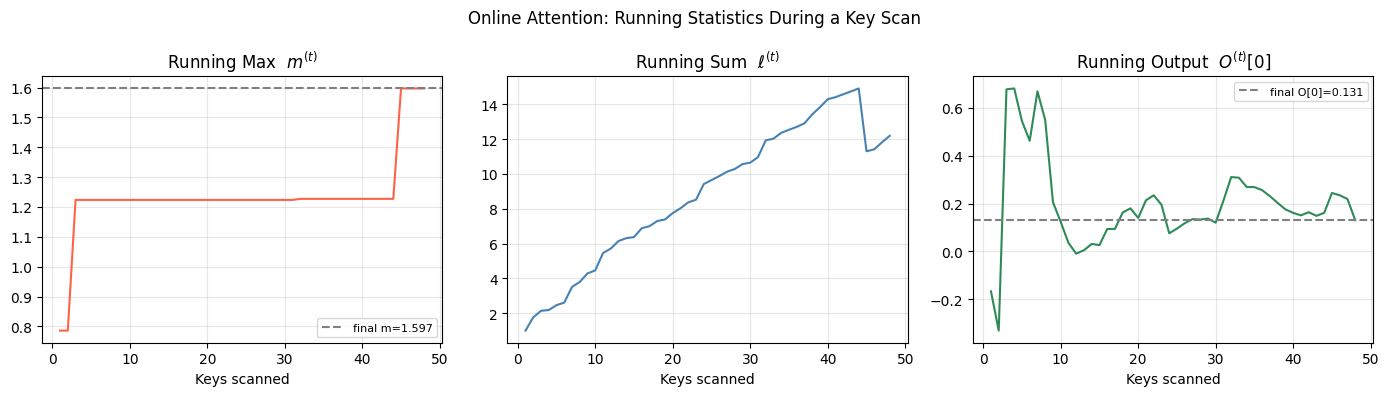

图像已保存至 results/02_online_convergence.png


In [7]:
d_k_vis, N_vis = 16, 48
q_v = torch.randn(d_k_vis)
K_v = torch.randn(N_vis, d_k_vis)
V_v = torch.randn(N_vis, d_k_vis)
scale_v = 1.0 / math.sqrt(d_k_vis)

# 追踪中间状态
m_history = []
ell_history = []
o0_history = []  # 输出第 0 维

m = torch.tensor(float("-inf"), dtype=q_v.dtype)
ell = torch.tensor(0.0, dtype=q_v.dtype)
O = torch.zeros(d_k_vis, dtype=q_v.dtype)

for j in range(N_vis):
    s_j = (q_v @ K_v[j]) * scale_v
    v_j = V_v[j]
    m_new = torch.maximum(m, s_j)
    ell_new = torch.exp(m - m_new) * ell + torch.exp(s_j - m_new)
    alpha = torch.exp(m - m_new) * ell / ell_new
    beta = torch.exp(s_j - m_new) / ell_new
    O = alpha * O + beta * v_j
    m, ell = m_new, ell_new
    m_history.append(m.item())
    ell_history.append(ell.item())
    o0_history.append(O[0].item())

# 真实最终值（参考）
s_all = (q_v @ K_v.T) * scale_v
a_all = torch.softmax(s_all, dim=0)
o_final = (a_all @ V_v)[0].item()
m_final = s_all.max().item()

steps = list(range(1, N_vis + 1))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(steps, m_history, color="tomato")
axes[0].axhline(m_final, linestyle="--", color="gray", label=f"final m={m_final:.3f}")
axes[0].set_title("Running Max  $m^{(t)}$")
axes[0].set_xlabel("Keys scanned")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(steps, ell_history, color="steelblue")
axes[1].set_title("Running Sum  $\\ell^{(t)}$")
axes[1].set_xlabel("Keys scanned")
axes[1].grid(alpha=0.3)

axes[2].plot(steps, o0_history, color="seagreen")
axes[2].axhline(o_final, linestyle="--", color="gray", label=f"final O[0]={o_final:.3f}")
axes[2].set_title("Running Output  $O^{(t)}[0]$")
axes[2].set_xlabel("Keys scanned")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("Online Attention: Running Statistics During a Key Scan", fontsize=12)
plt.tight_layout()
plt.savefig(results_dir / "02_online_convergence.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/02_online_convergence.png")

## 5 分块 Online Attention

将 $Q$ 按行分成每块最多 $B_r$ 行的块，将 $K,V$ 按行分成每块最多 $B_c$ 行的块：
$$
T_r=\lceil N/B_r\rceil,\qquad T_c=\lceil N/B_c\rceil.
$$
对每个块对 $(i,j)$，计算 $S_{ij}=Q_iK_j^\top/\sqrt{d_k}$，并逐行计算局部指数 $\tilde A_{ij}=\exp(S_{ij}-\tilde m_{ij})$。它尚未按整行归一化，因此不能直接当作完整 $A$ 的对应块。

记 $\alpha=e^{m_i^{\text{old}}-m_i^{\text{new}}}$、$\beta=e^{\tilde m_{ij}-m_i^{\text{new}}}$，按行广播后：
$$
\ell_i^{\text{new}}=\alpha\ell_i^{\text{old}}+\beta\tilde\ell_{ij},\qquad
O_i^{\text{new}}=\frac{\alpha\ell_i^{\text{old}}O_i^{\text{old}}+\beta\tilde A_{ij}V_j}{\ell_i^{\text{new}}}.
$$
外层遍历 $K/V$ 块，内层遍历 $Q$ 块，与 [本地 FlashAttention 论文](https://arxiv.org/abs/2205.14135) 第 5 页 Algorithm 1 的更新顺序相同。论文用 $d,P$，这里沿用 $d_k,A$ 并显式加入缩放。

因果模式遮蔽 key 位置大于 query 位置的项，`True` 表示遮蔽。当前块某一行全部遮蔽时，局部指数和分母贡献应为零，不能直接计算 $-\infty-(-\infty)$。

**这只是 PyTorch 算法演示。** 普通切片和算子不保证中间块驻留 SRAM；输入需要梯度时，代码可以交给 autograd 求导；这时会保存旧状态和计算图，反向显存不会自动保持线性。真正的 FlashAttention 需要融合 kernel 和重计算反向。半精度输入在本示例中转为 FP32 计算，输出再转回原类型，因此还包含转换开销。

单头、单样本的全注意力计算量仍为 $\Theta(N^2d_k)$。关闭梯度时，输出和行状态占 $O(Nd_k)$ 空间，临时块占 $O(B_rB_c)$ 空间。固定块大小和头维度时，空间随 $N$ 线性增长。

In [8]:
def block_statistics(Sij):
    m_tilde = Sij.amax(dim=-1)
    safe_max = torch.where(torch.isfinite(m_tilde), m_tilde, 0.0)
    A_tilde = torch.exp(Sij - safe_max.unsqueeze(-1))
    return m_tilde, A_tilde, A_tilde.sum(dim=-1)


# Algorithm 1 的分块前向演示
def tiled_online_attention(
    Q: torch.Tensor, # (B, h, N, d_k)
    K: torch.Tensor, # (B, h, N, d_k)
    V: torch.Tensor, # (B, h, N, d_k)
    block_r: int = 32, # Br：Q 块大小
    block_c: int = 32, # Bc：K/V 块大小
    causal: bool = False,
) -> torch.Tensor:
    """Algorithm 1 的前向演示，输出形状为 (B,h,N,d_k)。"""
    if not isinstance(block_r, int) or not isinstance(block_c, int) or block_r <= 0 or block_c <= 0:
        raise ValueError("块大小必须为正整数")
    if Q.ndim != 4 or Q.shape != K.shape or Q.shape != V.shape or min(Q.shape) == 0:
        raise ValueError("Q,K,V 必须是相同的非空 (B,h,N,d_k) 张量")
    if not Q.is_floating_point() or Q.dtype != K.dtype or Q.dtype != V.dtype:
        raise ValueError("Q,K,V 必须使用相同的浮点类型")
    if Q.device != K.device or Q.device != V.device:
        raise ValueError("Q,K,V 必须位于同一设备")
    output_dtype = Q.dtype
    if Q.dtype in (torch.float16, torch.bfloat16):
        Q, K, V = Q.float(), K.float(), V.float()
    B, h, N, d_k = Q.shape
    scale = 1.0 / math.sqrt(d_k)
    Tr = math.ceil(N / block_r)
    Tc = math.ceil(N / block_c)

    # 初始化 O, ℓ, m（对应论文中的 HBM 状态）
    O = torch.zeros_like(Q)                                              # (B,h,N,d_k)
    ell = torch.zeros(B, h, N, device=Q.device, dtype=Q.dtype)            # (B,h,N)
    m = torch.full((B, h, N), float("-inf"), device=Q.device, dtype=Q.dtype)  # (B,h,N)

    # 外循环 j（K/V 列块）
    for j in range(Tc):
        j0, j1 = j * block_c, min((j + 1) * block_c, N)
        # 取出当前 K/V 块，真实融合 kernel 会在片上复用
        Kj = K[:, :, j0:j1, :]    # (B,h,Bc',d_k)
        Vj = V[:, :, j0:j1, :]    # (B,h,Bc',d_k)

        # 内循环 i（Q 行块）
        for i in range(Tr):
            i0, i1 = i * block_r, min((i + 1) * block_r, N)
            # 取出当前 Q 块和旧状态
            Qi  = Q[:, :, i0:i1, :]   # (B,h,Br',d_k)
            Oi  = O[:, :, i0:i1, :]   # (B,h,Br',d_k)
            ell_i  = ell[:, :, i0:i1]      # (B,h,Br')
            mi  = m[:, :, i0:i1]      # (B,h,Br')

            # 计算局部分数 Sᵢⱼ（融合 kernel 中在片上）
            Sij = torch.matmul(Qi, Kj.transpose(-2, -1)) * scale  # (B,h,Br',Bc')

            # grad 模式下保存旧值，避免后面的原地回写覆盖 autograd 所需的张量。
            if torch.is_grad_enabled():
                Oi, ell_i, mi = Oi.clone(), ell_i.clone(), mi.clone()

            # 因果掩码（遮蔽 k_pos > q_pos 的位置）
            if causal and j1 - 1 > i0:
                q_pos = torch.arange(i0, i1, device=Q.device).view(1, 1, -1, 1)
                k_pos = torch.arange(j0, j1, device=Q.device).view(1, 1, 1, -1)
                Sij = Sij.masked_fill(k_pos > q_pos, float("-inf"))

            # 局部统计量（真实融合 kernel 不写 S/A 到 HBM）
            m_tilde, A_tilde, ell_tilde = block_statistics(Sij)

            # Online Softmax：合并全局统计量
            mi_new = torch.maximum(mi, m_tilde)
            alpha = torch.exp(mi - mi_new)
            beta = torch.exp(m_tilde - mi_new)  # 空行 m_tilde=-inf，贡献为 0
            ell_i_new = alpha * ell_i + beta * ell_tilde
            Oi_new = (
                (alpha * ell_i).unsqueeze(-1) * Oi
                + beta.unsqueeze(-1) * torch.matmul(A_tilde, Vj)
            ) / ell_i_new.unsqueeze(-1)

            # 更新全局输出和行状态
            O[:, :, i0:i1, :] = Oi_new
            ell[:, :, i0:i1]    = ell_i_new
            m[:, :, i0:i1]    = mi_new

    return O.to(output_dtype)

In [9]:
torch.manual_seed(42)
B, h, N, d_k = 2, 4, 65, 32
Q = torch.randn(B, h, N, d_k, device=device)
K = torch.randn_like(Q)
V = torch.randn_like(Q)
with torch.no_grad():
    for causal in [False, True]:
        with select_backend('math'):
            ref = F.scaled_dot_product_attention(Q, K, V, is_causal=causal)
        print(f'因果模式：{causal}')
        for br, bc in [(8, 8), (16, 16), (32, 32), (7, 13), (128, 128)]:
            out = tiled_online_attention(Q, K, V, block_r=br, block_c=bc, causal=causal)
            torch.testing.assert_close(out, ref, atol=1e-5, rtol=1e-4)
            print(f'Br={br:3d}, Bc={bc:3d}，最大绝对误差={(out-ref).abs().max().item():.2e}')
            validation_checks.append({
                'method': 'tiled_online_attention', 'reference': 'forced SDPA math',
                'shape': list(Q.shape), 'dtype': str(Q.dtype), 'causal': causal,
                'block_r': br, 'block_c': bc, 'status': 'passed',
                'atol': 1e-5, 'rtol': 1e-4,
                'max_abs_error': float((out-ref).abs().max().item()),
                'relative_l2': float(((out-ref).norm()/ref.norm()).item()),
            })


因果模式：False


Br=  8, Bc=  8，最大绝对误差=5.36e-07


Br= 16, Bc= 16，最大绝对误差=5.36e-07


Br= 32, Bc= 32，最大绝对误差=4.17e-07
Br=  7, Bc= 13，最大绝对误差=5.96e-07
Br=128, Bc=128，最大绝对误差=4.77e-07
因果模式：True


Br=  8, Bc=  8，最大绝对误差=5.96e-07
Br= 16, Bc= 16，最大绝对误差=5.51e-07
Br= 32, Bc= 32，最大绝对误差=6.26e-07
Br=  7, Bc= 13，最大绝对误差=5.36e-07
Br=128, Bc=128，最大绝对误差=6.26e-07


## 6 数值精度分析

Online 更新在精确算术下等价于整行计算，但分块改变了浮点运算顺序。块大小、输入类型、累积精度和分数大小都会影响误差，不能只凭块大小判断误差，也不能把一组输入上的误差当作所有输入的保证。

下面以原始 FP32 输入的 FP64 math 输出为参考，比较 FP32 和 FP16 输入的结果。本示例两者都至少用 FP32 累积；FP16 曲线还包含输入转为 FP16 及输出转回 FP16 的舍入误差。另记录 FP16 输入相对于相同输入的 FP64 参考误差，帮助判断输入量化和后续计算各自的影响。三项最大绝对误差不能直接相加。

这里展示的是本示例的精度，不代表真实 Flash kernel 的全部混合精度细节，也不预先断言块越大就越准确。

仅输入转为 FP16 导致的输出差异：7.21e-04


块=  8，FP32=2.07e-07，FP16 总误差=6.93e-04，相同 FP16 输入误差=2.24e-04
块= 16，FP32=2.66e-07，FP16 总误差=6.93e-04，相同 FP16 输入误差=2.24e-04
块= 32，FP32=3.32e-07，FP16 总误差=6.93e-04，相同 FP16 输入误差=2.24e-04
块= 64，FP32=3.32e-07，FP16 总误差=6.93e-04，相同 FP16 输入误差=2.24e-04
块=128，FP32=3.03e-07，FP16 总误差=6.93e-04，相同 FP16 输入误差=2.24e-04


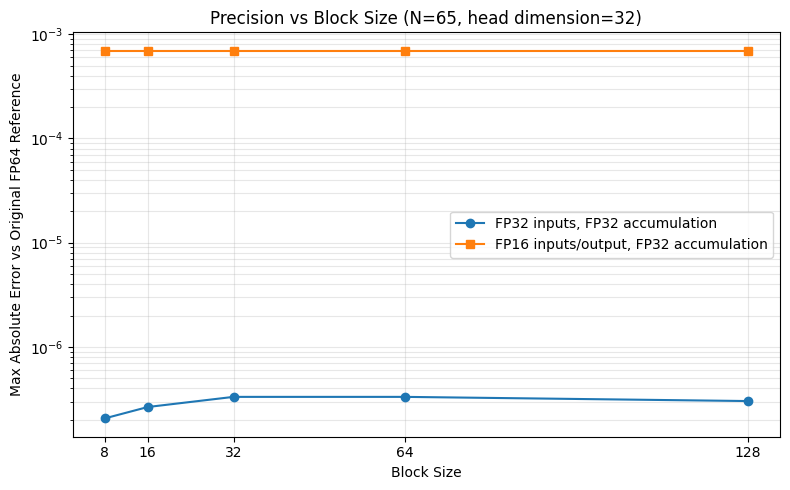

已保存分块前向与精度检查数据：02_validation_online_softmax.json


In [10]:
torch.manual_seed(0)
B2, h2, N2, d_k2 = 1, 1, 65, 32
Q2 = torch.randn(B2, h2, N2, d_k2, device=device)
K2 = torch.randn_like(Q2)
V2 = torch.randn_like(Q2)
Q2h, K2h, V2h = Q2.half(), K2.half(), V2.half()
with torch.no_grad(), select_backend('math'):
    ref_fp64 = F.scaled_dot_product_attention(Q2.double(), K2.double(), V2.double())
    ref_half_inputs = F.scaled_dot_product_attention(Q2h.double(), K2h.double(), V2h.double())
input_error = (ref_half_inputs-ref_fp64).abs().max().item()
print(f'仅输入转为 FP16 导致的输出差异：{input_error:.2e}')

block_sizes = [8, 16, 32, 64, 128]
errors_fp32, errors_fp16 = [], []
with torch.no_grad():
    for bs in block_sizes:
        out32 = tiled_online_attention(Q2, K2, V2, block_r=bs, block_c=bs)
        out16 = tiled_online_attention(Q2h, K2h, V2h, block_r=bs, block_c=bs)
        err32 = (out32.double()-ref_fp64).abs().max().item()
        err16 = (out16.double()-ref_fp64).abs().max().item()
        same_input_error = (out16.double()-ref_half_inputs).abs().max().item()
        assert torch.isfinite(out32).all() and torch.isfinite(out16).all()
        torch.testing.assert_close(out32.double(), ref_fp64, atol=1e-5, rtol=1e-4)
        torch.testing.assert_close(out16.double(), ref_half_inputs, atol=2e-3, rtol=2e-3)
        errors_fp32.append(err32)
        errors_fp16.append(err16)
        precision_checks.append({
            'shape': list(Q2.shape), 'block_size': bs, 'causal': False,
            'reference': 'forced SDPA math, FP64',
            'fp32_max_abs_error': float(err32), 'fp16_total_max_abs_error': float(err16),
            'fp16_same_input_max_abs_error': float(same_input_error),
            'fp16_input_only_max_abs_error': float(input_error), 'status': 'passed',
        })
        print(f'块={bs:3d}，FP32={err32:.2e}，FP16 总误差={err16:.2e}，相同 FP16 输入误差={same_input_error:.2e}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(block_sizes, errors_fp32, marker='o', label='FP32 inputs, FP32 accumulation')
ax.semilogy(block_sizes, errors_fp16, marker='s', label='FP16 inputs/output, FP32 accumulation')
ax.set_xlabel('Block Size')
ax.set_ylabel('Max Absolute Error vs Original FP64 Reference')
ax.set_title(f'Precision vs Block Size (N={N2}, head dimension={d_k2})')
ax.set_xticks(block_sizes)
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(results_dir / "02_precision_vs_blocksize.png", dpi=120, bbox_inches='tight')
plt.show()

(results_dir / '02_validation_online_softmax.json').write_text(
    json.dumps({'forward_checks': validation_checks, 'precision_checks': precision_checks},
               indent=2, ensure_ascii=False, allow_nan=False), encoding='utf-8'
)
print('已保存分块前向与精度检查数据：02_validation_online_softmax.json')


观察误差表和曲线，比较块大小变化带来的波动。FP16 总误差包含多种来源，不能全部归因于 Online Softmax 更新公式；相同输入的参考结果有助于区分这些影响。

## 7 性能对比与重复测量

比较强制 math 的标准实现、Python 分块实现和自动 SDPA。相同长度下使用同一组输入，关闭梯度和 dropout，只测前向。CUDA 使用 FP16，CPU 使用 FP32；Python 原型将半精度输入转为 FP32 运算。

本次复测采用 **5 轮重复测量，每轮预热 5 次、计时 10 次**。每轮循环调整三种实现的测试顺序；CPU 线程数固定为 1。延迟使用同步 CUDA 的 `torch.utils.benchmark.Timer`，每轮得到单次调用的平均值，最后用五个轮均值的**中位数**作为 `latency_ms`，同时保存每轮值、最小值、最大值和四分位数。图中误差条表示轮均值的最小–最大范围，属于实测波动范围。

每轮另外测量调用新增峰值已分配显存，扣除已有输入，包含输出、临时张量和 FP32 转换；最终取五轮中的最大值。CPU 显存记为 `null`。配置、版本、时间和测量协议均写入原始 JSON。

旧记录曾出现 $N=512$ 比 $N=1024$ 更慢的异常跳变。本次从相同配置重新测量，不预先排除任何轮次。重复实验用于检查当前稳定性，历史异常的具体原因仍需环境监控或 profiler 证据。自动 SDPA 的实际后端未逐点采集。

In [11]:
import torch.utils.benchmark as benchmark
from datetime import datetime, timezone

torch.set_num_threads(1)
N_ROUNDS, N_WARMUP, N_REPEAT = 5, 5, 10

@torch.no_grad()
def measure(fn, *args, n_warmup=N_WARMUP, n_repeat=N_REPEAT, label=''):
    dev = args[0].device
    for _ in range(n_warmup):
        fn(*args)
    if dev.type == 'cuda':
        torch.cuda.synchronize(dev)
        baseline = torch.cuda.memory_allocated(dev)
        torch.cuda.reset_peak_memory_stats(dev)
        out = fn(*args)
        torch.cuda.synchronize(dev)
        mem_mb = (torch.cuda.max_memory_allocated(dev)-baseline) / 1e6
        del out
    else:
        mem_mb = None
    measured = benchmark.Timer(
        stmt='fn(*args)', globals={'fn': fn, 'args': args}, num_threads=1
    ).timeit(n_repeat)
    return dict(latency_ms=float(measured.mean*1e3), memory_mb=mem_mb)

def run_tiled(Q, K, V):
    return tiled_online_attention(Q, K, V, block_r=32, block_c=32)

def run_sdpa_default(Q, K, V):
    return F.scaled_dot_product_attention(Q, K, V, dropout_p=0.0)

SEQ_LENS = [128, 256, 512, 1024] if device == 'cuda' else [128, 256, 512]
D_K, HEADS, BATCH = 64, 4, 1
records = []
impls = [('standard (math)', run_standard), ('tiled_online', run_tiled),
         ('F.sdpa (default)', run_sdpa_default)]
measured_at = datetime.now(timezone.utc).isoformat()

for N3 in SEQ_LENS:
    torch.manual_seed(0)
    dtype = torch.float16 if device == 'cuda' else torch.float32
    Qb = torch.randn(BATCH, HEADS, N3, D_K, device=device, dtype=dtype)
    Kb, Vb = torch.randn_like(Qb), torch.randn_like(Qb)
    samples = {name: [] for name, _ in impls}
    failures = {}
    for round_index in range(N_ROUNDS):
        ordered = impls[round_index % len(impls):] + impls[:round_index % len(impls)]
        for name, fn in ordered:
            if name in failures:
                continue
            try:
                result = measure(fn, Qb, Kb, Vb, label=name)
                samples[name].append(result)
            except torch.cuda.OutOfMemoryError as exc:
                failures[name] = str(exc)
                torch.cuda.empty_cache()
        print(f'N={N3}, round={round_index + 1}/{N_ROUNDS} completed', flush=True)
    for name, _ in impls:
        rec = dict(
            impl=name, seq_len=N3, dtype=str(dtype), device=str(Qb.device),
            batch=BATCH, heads=HEADS, d_k=D_K, causal=False, dropout_p=0.0,
            grad_enabled=False, cpu_num_threads=1, torch_version=torch.__version__,
            timing_iterations=N_REPEAT, timing_rounds=N_ROUNDS, warmup_iterations=N_WARMUP,
            latency_aggregation='median_of_round_means',
            memory_metric='incremental_peak_allocated', memory_aggregation='max_of_rounds',
            block_r=32 if name == 'tiled_online' else None,
            block_c=32 if name == 'tiled_online' else None,
            measured_at_utc=measured_at,
        )
        if name in failures:
            rec.update(status='oom', reason=failures[name], latency_ms=None, memory_mb=None)
        else:
            values = [row['latency_ms'] for row in samples[name]]
            memory_values = [row['memory_mb'] for row in samples[name] if row['memory_mb'] is not None]
            rec.update(
                status='ok', latency_ms=float(np.median(values)),
                latency_samples_ms=values,
                latency_min_ms=float(min(values)), latency_max_ms=float(max(values)),
                latency_p25_ms=float(np.percentile(values, 25)),
                latency_p75_ms=float(np.percentile(values, 75)),
                memory_mb=float(max(memory_values)) if memory_values else None,
                memory_samples_mb=memory_values,
            )
        records.append(rec)
        print(rec, flush=True)
    del Qb, Kb, Vb

(results_dir / '02_benchmark_online_softmax.json').write_text(
    json.dumps(records, indent=2, ensure_ascii=False, allow_nan=False), encoding='utf-8'
)
print('结果已保存至 results/02_benchmark_online_softmax.json')

N=128, round=1/5 completed


N=128, round=2/5 completed


N=128, round=3/5 completed


N=128, round=4/5 completed


N=128, round=5/5 completed


...

N=1024, round=5/5 completed


{'impl': 'standard (math)', 'seq_len': 1024, 'dtype': 'torch.float16', 'device': 'cuda:0', 'batch': 1, 'heads': 4, 'd_k': 64, 'causal': False, 'dropout_p': 0.0, 'grad_enabled': False, 'cpu_num_threads': 1, 'torch_version': '2.11.0+cu128', 'timing_iterations': 10, 'timing_rounds': 5, 'warmup_iterations': 5, 'latency_aggregation': 'median_of_round_means', 'memory_metric': 'incremental_peak_allocated', 'memory_aggregation': 'max_of_rounds', 'block_r': None, 'block_c': None, 'measured_at_utc': '2026-10-04T22:56:19.146840+00:00', 'status': 'ok', 'latency_ms': 29.94223040000179, 'latency_samples_ms': [29.709016300000712, 29.94223040000179, 29.817371400002912, 32.01540109999996, 115.20115289999922], 'latency_min_ms': 29.709016300000712, 'latency_max_ms': 115.20115289999922, 'latency_p25_ms': 29.817371400002912, 'latency_p75_ms': 32.01540109999996, 'memory_mb': 41.947648, 'memory_samples_mb': [41.947648, 41.947648, 41.947648, 41.947648, 41.947648]}


{'impl': 'tiled_online', 'seq_len': 1024, 'dtype': 'torch.float16', 'device': 'cuda:0', 'batch': 1, 'heads': 4, 'd_k': 64, 'causal': False, 'dropout_p': 0.0, 'grad_enabled': False, 'cpu_num_threads': 1, 'torch_version': '2.11.0+cu128', 'timing_iterations': 10, 'timing_rounds': 5, 'warmup_iterations': 5, 'latency_aggregation': 'median_of_round_means', 'memory_metric': 'incremental_peak_allocated', 'memory_aggregation': 'max_of_rounds', 'block_r': 32, 'block_c': 32, 'measured_at_utc': '2026-10-04T22:56:19.146840+00:00', 'status': 'ok', 'latency_ms': 4016.9204654999985, 'latency_samples_ms': [4016.9204654999985, 2427.073773799998, 2550.9891174000018, 5705.851100600001, 5642.397751700002], 'latency_min_ms': 2427.073773799998, 'latency_max_ms': 5705.851100600001, 'latency_p25_ms': 2550.9891174000018, 'latency_p75_ms': 5642.397751700002, 'memory_mb': 4.819968, 'memory_samples_mb': [4.819968, 4.819968, 4.819968, 4.819968, 4.819968]}


{'impl': 'F.sdpa (default)', 'seq_len': 1024, 'dtype': 'torch.float16', 'device': 'cuda:0', 'batch': 1, 'heads': 4, 'd_k': 64, 'causal': False, 'dropout_p': 0.0, 'grad_enabled': False, 'cpu_num_threads': 1, 'torch_version': '2.11.0+cu128', 'timing_iterations': 10, 'timing_rounds': 5, 'warmup_iterations': 5, 'latency_aggregation': 'median_of_round_means', 'memory_metric': 'incremental_peak_allocated', 'memory_aggregation': 'max_of_rounds', 'block_r': None, 'block_c': None, 'measured_at_utc': '2026-10-04T22:56:19.146840+00:00', 'status': 'ok', 'latency_ms': 3.4986540999966564, 'latency_samples_ms': [3.497060600000168, 3.4986540999966564, 3.4782796999991206, 15.90682560000687, 14.09446709999429], 'latency_min_ms': 3.4782796999991206, 'latency_max_ms': 15.90682560000687, 'latency_p25_ms': 3.497060600000168, 'latency_p75_ms': 14.09446709999429, 'memory_mb': 0.541696, 'memory_samples_mb': [0.541696, 0.541696, 0.541696, 0.541696, 0.541696]}


结果已保存至 results/02_benchmark_online_softmax.json


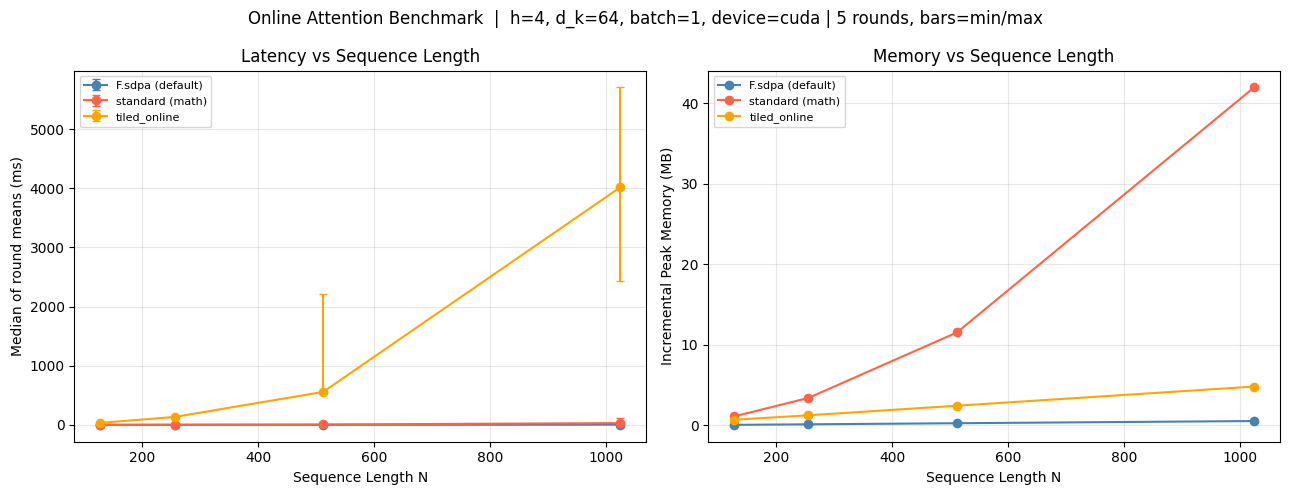

图像已保存至 results/02_benchmark_plot.png


In [12]:
import pandas as pd

df = pd.DataFrame(records)
df = df[df["status"] == "ok"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"standard (math)": "tomato", "tiled_online": "orange", "F.sdpa (default)": "steelblue"}

for ax, metric, ylabel, title in [
    (axes[0], "latency_ms", "Median of round means (ms)",    "Latency vs Sequence Length"),
    (axes[1], "memory_mb",  "Incremental Peak Memory (MB)", "Memory vs Sequence Length"),
]:
    for impl, grp in df.groupby("impl"):
        g = grp.sort_values("seq_len")
        valid = g.dropna(subset=[metric])
        if valid.empty:
            continue
        if metric == 'latency_ms':
            yerr = np.vstack([valid[metric] - valid['latency_min_ms'],
                              valid['latency_max_ms'] - valid[metric]])
            ax.errorbar(valid['seq_len'], valid[metric], yerr=yerr, capsize=3,
                        marker='o', label=impl, color=colors.get(impl))
        else:
            ax.plot(valid['seq_len'], valid[metric],
                    marker='o', label=impl, color=colors.get(impl))
    ax.set_xlabel("Sequence Length N")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ax.lines:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f"Online Attention Benchmark  |  h={HEADS}, d_k={D_K}, batch={BATCH}, device={device} | 5 rounds, bars=min/max")
plt.tight_layout()
plt.savefig(results_dir / "02_benchmark_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/02_benchmark_plot.png")

结合中位数、误差条和显存曲线判断收益。分块前向避免生成完整权重矩阵，但 Python 循环、小算子调度和精度转换可能增加延迟；没有 profiler 时，无法为这些原因分配具体占比。五轮重复反映本次运行的波动，也不保证换一台设备或换一次负载后相同。

这组关闭梯度的前向测试不说明训练峰值显存。当前保存的检查与精度数据见 `02_validation_online_softmax.json`；性能记录包含全部轮次，不筛选最快轮次作为最终结果。

## 8 小结与展望

| 概念 | 核心内容 |
|------|----------|
| Safe Softmax | 减去最大值，避免有限输入的指数溢出 |
| Online Softmax | 一趟求出 $m,\ell$；完整权重仍需要访问输入或保存的中间值 |
| 更新规则 | 新最大值改变指数基准，旧分母和旧输出分子都要同步缩放 |
| Online Attention | 累积 $\tilde O$ 后归一化，或逐步维护 $O$，无需完整 $A$ |
| 块级合并 | 精确算术下满足结合律；浮点合并顺序可能带来误差 |
| Tiling | 每行维护 $m,\ell,O$，块内用矩阵乘，支持 batch 和多头 |
| 精度与性能 | 与输入、工作精度、块大小和实现有关，需要实测 |

Online 更新解决了分块时不知道最终 softmax 分母的问题。FlashAttention 把这些公式放进融合 kernel，控制块在片上的复用，并在反向传播中重计算中间量。

下一节 [03_flash_attention.ipynb](03_flash_attention.ipynb) 将分析 IO 复杂度、块大小选择和反向重计算，并用 SDPA 测量实际效果。

**参考文献**

- [FlashAttention，NeurIPS 2022，本地 PDF](https://arxiv.org/abs/2205.14135)
- [Online normalizer calculation for softmax，2018](https://arxiv.org/abs/1805.02867)